In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG, display
from matplotlib.lines import Line2D
from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit
from scipy.stats import kendalltau
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import r2_score

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent

LOCAL_DATA_DIR = PROJECT_DIR / "local_data"
DATABASE_PATH = LOCAL_DATA_DIR / "ani_microbial_eukaryotes.duckdb"
METADATA_PATH = PROJECT_DIR / "assets" / "genome_tax_metadata.parquet"

MARKER_PAIRS_PATH = Path(os.environ.get(
    "ANI_EUK_MARKER_PAIRS",
    PROJECT_DIR / "tmp_data/marker-pairwise-results.parquet"
))

for required_path in (DATABASE_PATH, METADATA_PATH, MARKER_PAIRS_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

FIGS_DIR = PROJECT_DIR / "assets" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE4_SVG = FIGS_DIR / "fig-4.svg"
FIGURE4_PNG = FIGS_DIR / "fig-4.png"
FIGURE4_PDF = FIGS_DIR / "fig-4.pdf"

PUBLICATION_FONT = "Nimbus Sans"
PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": [PUBLICATION_FONT, "Arial", "Helvetica", "DejaVu Sans"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)

RANK_ORDER = ["species", "genus", "family", "order", "class", "phylum", "domain"]
#ANI_MIN = 75.0
#AF_MIN = 0.20
MARKER_IDENTITY_MIN = 50.0
ITS_ALIGNMENT_LENGTH_MIN = 50

def sql_path(path):
    return str(path).replace("'", "''")

In [2]:
con = duckdb.connect(str(DATABASE_PATH), read_only=True)
con.execute("SET threads=4")
con.execute("SET max_expression_depth=100000")
con.execute("SET preserve_insertion_order=false")
con.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW retained_genomes AS
    SELECT ncbi_genome_accession
    FROM read_parquet('{sql_path(METADATA_PATH)}')
    WHERE qc = 'pass'
    """
)
print(f"Using analysis database: {DATABASE_PATH.relative_to(PROJECT_DIR)}")
print(f"Using taxonomy/QC metadata: {METADATA_PATH.relative_to(PROJECT_DIR)}")

Using analysis database: local_data/ani_microbial_eukaryotes.duckdb


In [3]:
its_panels = con.execute(
    f"""
    WITH ani_pairs AS (
        SELECT
            g1.ncbi_genome_accession AS genome1,
            g2.ncbi_genome_accession AS genome2,
            p.ani AS ANI,
            p.lca_2026_09_01 AS LCA
        FROM analysis_pairwise_metrics p
        JOIN genomes g1 ON p.genome1_id = g1.genome_id
        JOIN genomes g2 ON p.genome2_id = g2.genome_id
        JOIN retained_genomes r1 ON g1.ncbi_genome_accession = r1.ncbi_genome_accession
        JOIN retained_genomes r2 ON g2.ncbi_genome_accession = r2.ncbi_genome_accession
        WHERE p.lca_2026_09_01 IN ({','.join(repr(rank) for rank in RANK_ORDER)})
    ),
    marker_pairs AS (
        SELECT genome1, genome2, region, marker_identity
        FROM read_parquet('{sql_path(MARKER_PAIRS_PATH)}')
        WHERE region IN ('ITS1', 'ITS2')
          AND marker_identity BETWEEN {MARKER_IDENTITY_MIN} AND 100
          AND alignment_length >= {ITS_ALIGNMENT_LENGTH_MIN}
    )
    SELECT p.genome1, p.genome2, p.ANI, p.LCA,
           m.region, m.marker_identity
    FROM ani_pairs p
    JOIN marker_pairs m
      ON m.genome1 = least(p.genome1, p.genome2)
     AND m.genome2 = greatest(p.genome1, p.genome2)
    """
).fetchdf()

con.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW panel_c_all AS
    SELECT ani AS ANI, aai AS AAI, lca_2026_09_01 AS LCA
    FROM analysis_pairwise_metrics p
    JOIN genomes g1 ON p.genome1_id = g1.genome_id
    JOIN genomes g2 ON p.genome2_id = g2.genome_id
    JOIN retained_genomes r1 ON g1.ncbi_genome_accession = r1.ncbi_genome_accession
    JOIN retained_genomes r2 ON g2.ncbi_genome_accession = r2.ncbi_genome_accession
    WHERE aai > 0
      AND lca_2026_09_01 IN ({','.join(repr(rank) for rank in RANK_ORDER)})
    """
)

con.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW panel_d_all AS
    SELECT aai AS AAI, shared_gene_content AS SGC, lca_2026_09_01 AS LCA
    FROM analysis_pairwise_metrics p
    JOIN genomes g1 ON p.genome1_id = g1.genome_id
    JOIN genomes g2 ON p.genome2_id = g2.genome_id
    JOIN retained_genomes r1 ON g1.ncbi_genome_accession = r1.ncbi_genome_accession
    JOIN retained_genomes r2 ON g2.ncbi_genome_accession = r2.ncbi_genome_accession
    WHERE aai >= 30 AND shared_gene_content > 0
      AND lca_2026_09_01 IN ({','.join(repr(rank) for rank in RANK_ORDER)})
    """
)

panel_c = con.execute("SELECT * FROM panel_c_all").fetchdf()
panel_d = con.execute("SELECT * FROM panel_d_all").fetchdf()

panel_a = its_panels.loc[its_panels['region'].eq('ITS1'), ['ANI', 'marker_identity', 'LCA']].copy()
panel_b = its_panels.loc[its_panels['region'].eq('ITS2'), ['ANI', 'marker_identity', 'LCA']].copy()
for frame in (panel_a, panel_b, panel_c, panel_d):
    frame['LCA'] = pd.Categorical(frame['LCA'].astype(str).str.lower(), categories=RANK_ORDER, ordered=True)

print(f"Panel A (ANI–ITS1): {len(panel_a):,} pairs")
print(f"Panel B (ANI–ITS2): {len(panel_b):,} pairs")
print(f"Panel C (ANI–AAI): {len(panel_c):,} pairs")
print(f"Panel D (AAI–SGC): {len(panel_d):,} pairs")

Panel A (ANI–ITS1): 1,681,528 pairs
Panel B (ANI–ITS2): 1,887,623 pairs
Panel C (ANI–AAI): 23,862,289 pairs
Panel D (AAI–SGC): 23,862,289 pairs


In [4]:
def hybrid_model(x, L, k, x0, m):
    return L / (1 + np.exp(np.clip(-k * (x - x0), -700, 700))) + m * x


def duckdb_hybrid_summary(relation, x_col, y_col, params):
    if relation not in {'panel_c_all', 'panel_d_all'}:
        raise ValueError(f'Unexpected DuckDB relation: {relation}')
    if x_col not in {'ANI', 'AAI'} or y_col not in {'AAI', 'SGC'}:
        raise ValueError('Unexpected metric column')
    L, k, x0, m = (float(value) for value in params)
    prediction = (
        f'{L} / (1 + exp(least(greatest(-{k} * ({x_col} - {x0}), -700), 700))) '
        f'+ {m} * {x_col}'
    )
    row = con.execute(
        f'''
        WITH scored AS (
            SELECT {x_col}::DOUBLE AS x, {y_col}::DOUBLE AS y,
                   ({prediction})::DOUBLE AS y_pred
            FROM {relation}
        ),
        moments AS (
            SELECT count(*) AS n, avg(y) AS mean_y, min(x) AS min_x, max(x) AS max_x
            FROM scored
        )
        SELECT m.n, m.min_x, m.max_x,
               1 - sum(power(s.y - s.y_pred, 2))
                   / nullif(sum(power(s.y - m.mean_y, 2)), 0) AS r2
        FROM scored s CROSS JOIN moments m
        GROUP BY m.n, m.min_x, m.max_x
        '''
    ).fetchone()
    return {'n': int(row[0]), 'min_x': float(row[1]), 'max_x': float(row[2]), 'r2': float(row[3])}


def fit_hybrid_curve(
    df, x_col, y_col, p0, full_relation=None, report_kendall=False
):
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    params, _ = curve_fit(hybrid_model, x, y, p0=p0, maxfev=50000)
    if full_relation is None:
        y_pred = hybrid_model(x, *params)
        summary = {
            'n': len(x), 'min_x': float(x.min()), 'max_x': float(x.max()),
            'r2': float(r2_score(y, y_pred)),
        }
    else:
        summary = duckdb_hybrid_summary(full_relation, x_col, y_col, params)
    x_curve = np.linspace(summary['min_x'], summary['max_x'], 400)
    result = {
        'x_curve': x_curve,
        'y_curve': hybrid_model(x_curve, *params),
        'r2': summary['r2'],
        'n': summary['n'],
        'fit_label': 'Hybrid fit',
    }
    if report_kendall:
        tau, tau_p = kendalltau(x, y)
        result['kendall_tau'] = float(tau)
        result['kendall_p'] = float(tau_p)
    return result


def fit_monotonic_binned_curve(df, x_col, y_col, bin_width=0.25):
    work = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work['bin_id'] = np.floor((work[x_col]) / bin_width).astype(int)
    binned = (
        work.groupby('bin_id', observed=True)
        .agg(x=(x_col, 'median'), y=(y_col, 'median'), n=(y_col, 'size'))
        .reset_index(drop=True)
    )
    weights = np.sqrt(binned['n'].to_numpy(dtype=float))
    isotonic = IsotonicRegression(
        increasing=True, y_min=MARKER_IDENTITY_MIN, y_max=100, out_of_bounds='clip'
    )
    y_pred = isotonic.fit_transform(binned['x'], binned['y'], sample_weight=weights)
    spline = PchipInterpolator(binned['x'].to_numpy(), y_pred)
    weighted_mean = np.average(binned['y'], weights=weights)
    weighted_r2 = 1 - (
        np.sum(weights * (binned['y'].to_numpy() - y_pred) ** 2)
        / np.sum(weights * (binned['y'].to_numpy() - weighted_mean) ** 2)
    )
    tau, tau_p = kendalltau(work[x_col], work[y_col])
    x_curve = np.linspace(binned['x'].min(), binned['x'].max(), 400)
    return {
        'x_curve': x_curve,
        'y_curve': np.clip(spline(x_curve), MARKER_IDENTITY_MIN, 100),
        'r2': float(weighted_r2),
        'n': len(work),
        'fit_label': 'Monotonic spline fit',
        'kendall_tau': float(tau),
        'kendall_p': float(tau_p),
    }


fit_results = {
    'A': fit_monotonic_binned_curve(panel_a, 'ANI', 'marker_identity'),
    'B': fit_monotonic_binned_curve(panel_b, 'ANI', 'marker_identity'),
    'C': fit_hybrid_curve(
        panel_c, 'ANI', 'AAI', [95, 0.15, 50, 0.02], full_relation='panel_c_all'
    ),
    'D': fit_hybrid_curve(
        panel_d, 'AAI', 'SGC', [95, 0.10, 50, 0.05], full_relation='panel_d_all'
    ),
}
con.close()
for label, result in fit_results.items():
    message = f"Panel {label}: N={result['n']:,}"
    if 'r2' in result:
        message += f", {result['fit_label'].lower()} R²={result['r2']:.3f}"
    else:
        message += f", {result['fit_label'].lower()} ({result['n_bins']} populated bins)"
    if 'kendall_tau' in result:
        message += f", Kendall τ={result['kendall_tau']:.3f} (p={result['kendall_p']:.3g})"
    print(message)

Panel A: N=885,001, monotonic spline fit R²=0.834, Kendall τ=0.314 (p=0)
Panel B: N=752,122, monotonic spline fit R²=0.806, Kendall τ=0.321 (p=0)
Panel C: N=23,862,289, hybrid fit R²=0.994
Panel D: N=23,862,289, hybrid fit R²=0.918


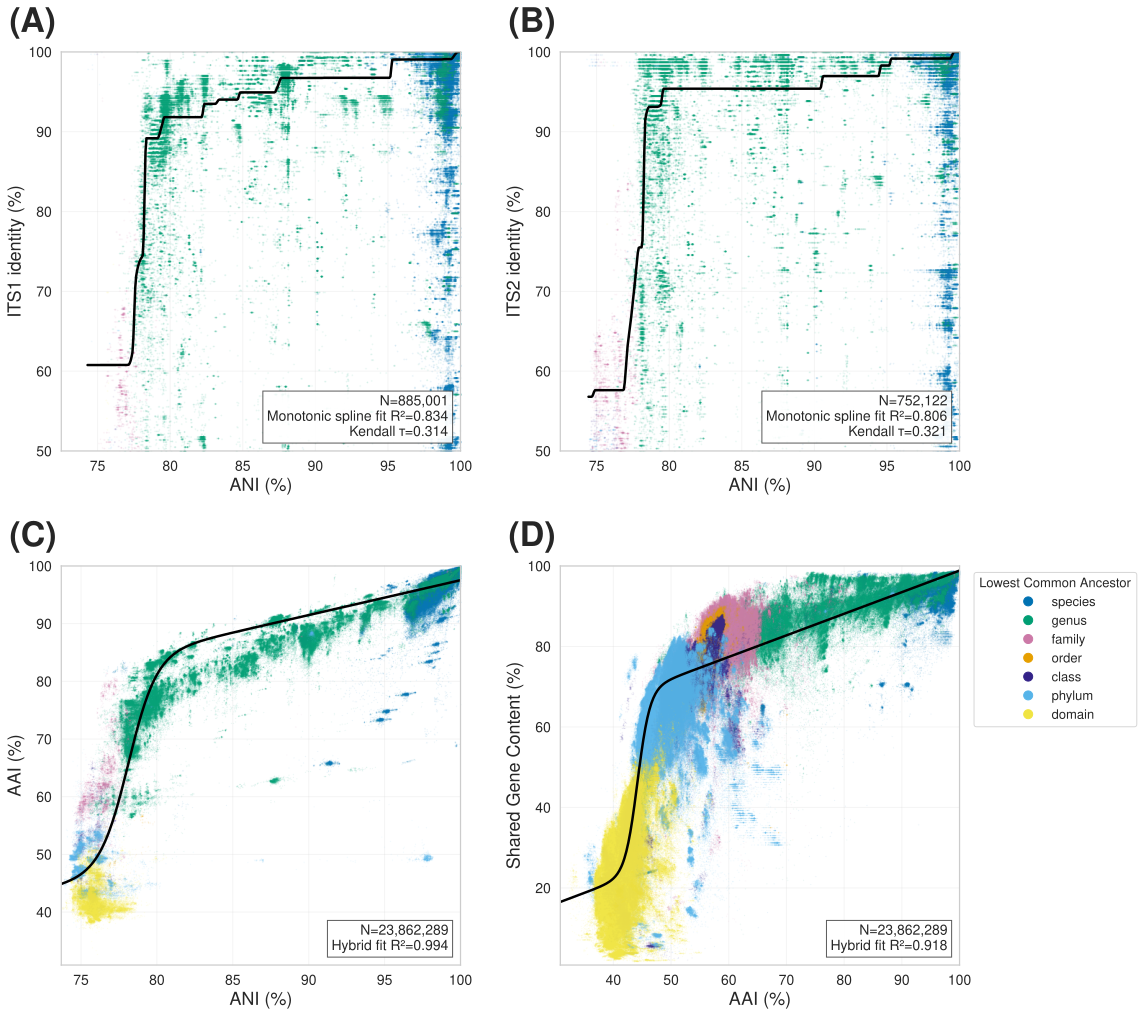

In [5]:
LABEL_SIZE = 18
TICK_SIZE = 14
ANNOTATION_SIZE = 14
PANEL_LABEL_SIZE = 34
LEGEND_SIZE = 13
SCATTER_SIZE = 1.0
ITS_SCATTER_SIZE = 2.0
SCATTER_ALPHA = 0.12
RANK_PALETTE = {
    'species': '#0072B2', 'genus': '#009E73', 'family': '#CC79A7',
    'order': '#E69F00', 'class': '#332288', 'phylum': '#56B4E9', 'domain': '#F0E442',
}
DRAW_ORDER = ['species', 'genus', 'family', 'order', 'class', 'phylum', 'domain']


def plot_rank_scatter(ax, data, x_col, y_col, point_size=SCATTER_SIZE):
    for rank in DRAW_ORDER:
        subset = data[data['LCA'] == rank]
        if not subset.empty:
            ax.scatter(
                subset[x_col], subset[y_col], s=point_size, alpha=SCATTER_ALPHA,
                color=RANK_PALETTE[rank], linewidths=0, rasterized=True,
            )


panels = [
    ('A', panel_a, 'ANI', 'marker_identity', 'ANI (%)', 'ITS1 identity (%)', (72.5, 100), (50, 100)),
    ('B', panel_b, 'ANI', 'marker_identity', 'ANI (%)', 'ITS2 identity (%)', (72.5, 100), (50, 100)),
    ('C', panel_c, 'ANI', 'AAI', 'ANI (%)', 'AAI (%)', (float(panel_c['ANI'].min()), 100), (float(panel_c['AAI'].min()), 100)),
    ('D', panel_d, 'AAI', 'SGC', 'AAI (%)', 'Shared Gene Content (%)', (float(panel_d['AAI'].min()), 100), (float(panel_d['SGC'].min()), 100)),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 15))
for ax, (label, data, x_col, y_col, x_label, y_label, xlim, ylim) in zip(axes.flat, panels):
    point_size = ITS_SCATTER_SIZE if label in {'A', 'B'} else SCATTER_SIZE
    plot_rank_scatter(ax, data, x_col, y_col, point_size=point_size)
    result = fit_results[label]
    if result.get('stepwise', False):
        ax.step(result['x_curve'], result['y_curve'], where='mid', color='black', linewidth=2.5)
    else:
        ax.plot(result['x_curve'], result['y_curve'], color='black', linewidth=2.5)
    ax.set(xlabel=x_label, ylabel=y_label, xlim=xlim, ylim=ylim)
    if label in {'A', 'B'}:
        ax.set_xticks(np.arange(75, 101, 5))
    ax.tick_params(labelsize=TICK_SIZE)
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)
    ax.grid(True, alpha=0.22)
    ax.set_box_aspect(1)
    stats_text = f"N={result['n']:,}"
    if 'r2' in result:
        stats_text += f"\n{result['fit_label']} R²={result['r2']:.3f}"
    else:
        stats_text += f"\n{result['fit_label']} ({result['n_bins']} bins)"
    if 'kendall_tau' in result:
        stats_text += f"\nKendall τ={result['kendall_tau']:.3f}"
    ax.text(
        0.97, 0.03, stats_text,
        transform=ax.transAxes, ha='right', va='bottom', fontsize=ANNOTATION_SIZE,
        bbox=dict(facecolor='white', edgecolor='0.3', alpha=0.92),
    )
    ax.text(-0.13, 1.05, f'({label})', transform=ax.transAxes, fontsize=PANEL_LABEL_SIZE, fontweight='bold')

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=RANK_PALETTE[rank], label=rank, markersize=9)
    for rank in RANK_ORDER
]
axes[1, 1].legend(
    handles=legend_handles, title='Lowest Common Ancestor', bbox_to_anchor=(1.02, 1),
    loc='upper left', fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE,
)
fig.subplots_adjust(left=0.08, right=0.86, top=0.95, bottom=0.07, hspace=0.18, wspace=0.25)
fig.savefig(FIGURE4_SVG, bbox_inches='tight')
fig.savefig(FIGURE4_PDF, bbox_inches='tight')
fig.savefig(FIGURE4_PNG, dpi=300, bbox_inches='tight')
plt.close(fig)
display(SVG(filename=str(FIGURE4_SVG)))